서울시 행정동별 10대 소비 트렌드 분석

기간: 24년 1~4월    
조사대상: 서울시 10대   
무엇을 분석하였는가: 행정동별 10대의 월별 서비스 업종별 매출 금액   
왜 분석을 하였는가: MZ세대의 소비 패턴을 분석하여 10대를 타겟으로 한 금융서비스 혹은 혜택 기획

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

In [2]:
df = pd.read_csv('D:/김동영/11_Github/mygit/개인분석/상권분석/Data/서울시 상권분석서비스(추정매출-행정동).csv', encoding='euc-kr')

In [3]:
df.head(5)

,기준_년분기_코드,행정동_코드,행정동_코드_명,서비스_업종_코드,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,월요일_매출_금액,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수
0,20241,11110515,청운효자동,CS100001,한식음식점,3282036149,102492,2359720647,922315502,381912382,...,25725,1622,49367,41053,470,12429,22034,18544,19637,17313
1,20241,11110515,청운효자동,CS100003,일식음식점,315907116,11835,225051104,90856012,26359701,...,2683,161,4925,6023,204,3395,2772,1733,1966,879
2,20241,11110515,청운효자동,CS100004,양식음식점,2582745698,49217,1540711320,1042034378,148589304,...,16503,2787,14393,32370,233,13771,14934,7816,6618,3394
3,20241,11110515,청운효자동,CS100005,제과점,548138245,41460,335822266,212315979,48215205,...,11458,351,13280,26768,216,8425,10838,7637,7641,5291
4,20241,11110515,청운효자동,CS100007,치킨전문점,78178614,2965,48075887,30102727,6755318,...,1889,496,1467,1406,24,303,667,593,747,537


In [4]:
df.columns

Index(['기준_년분기_코드', '행정동_코드', '행정동_코드_명', '서비스_업종_코드', '서비스_업종_코드_명',
       '당월_매출_금액', '당월_매출_건수', '주중_매출_금액', '주말_매출_금액', '월요일_매출_금액',
       '화요일_매출_금액', '수요일_매출_금액', '목요일_매출_금액', '금요일_매출_금액', '토요일_매출_금액',
       '일요일_매출_금액', '시간대_00~06_매출_금액', '시간대_06~11_매출_금액', '시간대_11~14_매출_금액',
       '시간대_14~17_매출_금액', '시간대_17~21_매출_금액', '시간대_21~24_매출_금액', '남성_매출_금액',
       '여성_매출_금액', '연령대_10_매출_금액', '연령대_20_매출_금액', '연령대_30_매출_금액',
       '연령대_40_매출_금액', '연령대_50_매출_금액', '연령대_60_이상_매출_금액', '주중_매출_건수',
       '주말_매출_건수', '월요일_매출_건수', '화요일_매출_건수', '수요일_매출_건수', '목요일_매출_건수',
       '금요일_매출_건수', '토요일_매출_건수', '일요일_매출_건수', '시간대_건수~06_매출_건수',
       '시간대_건수~11_매출_건수', '시간대_건수~14_매출_건수', '시간대_건수~17_매출_건수',
       '시간대_건수~21_매출_건수', '시간대_건수~24_매출_건수', '남성_매출_건수', '여성_매출_건수',
       '연령대_10_매출_건수', '연령대_20_매출_건수', '연령대_30_매출_건수', '연령대_40_매출_건수',
       '연령대_50_매출_건수', '연령대_60_이상_매출_건수'],
      dtype='object')

'기준_년분기_코드', '행정동_코드', '행정동_코드_명', '서비스_업종_코드', '서비스_업종_코드_명', '연령대_10_매출_금액', '연령대_20_매출_금액', '연령대_10_매출_건수', '연령대_20_매출_건수'

In [5]:
df['서비스_업종_코드_명'].unique()

array(['한식음식점', '일식음식점', '양식음식점', '제과점', '치킨전문점', '분식전문점', '호프-간이주점',
       '커피-음료', '일반교습학원', '예술학원', '스포츠 강습', '일반의원', '자동차미용', '미용실',
       '피부관리실', '세탁소', '가전제품수리', '슈퍼마켓', '편의점', '미곡판매', '육류판매', '수산물판매',
       '청과상', '반찬가게', '일반의류', '신발', '시계및귀금속', '의약품', '서적', '문구', '섬유제품',
       '화초', '인테리어', '중식음식점', '패스트푸드점', '치과의원', '한의원', '당구장', '스포츠클럽',
       '자동차수리', '네일숍', '여관', '노래방', '가방', '안경', '의료기기', '화장품', '가전제품',
       '가구', '전자상거래업', '핸드폰', '애완동물', '외국어학원', '골프연습장', 'PC방',
       '컴퓨터및주변장치판매', '철물점', '조명용품', '운동/경기용품', '부동산중개업', '고시원', '완구',
       '자전거 및 기타운송장비'], dtype=object)

구별 MZ 세대 서비스 업종 매출 분석    
서울시 모든 지역구를 대상으로 하기보다는 10대 청소년이 가장 많이 분포하는 동네를 선정해 분석    
기준: 10대 청소년이 가장 많이 분포 지역구 6군데 선정하여 진행.   
10대 청소년 모집단이 적은 지역까지 포함하게 되면 데이터에 왜곡이 발생할 수 있다고 판단해 제외하였다.    
또한, 집단 전체의 소비 성향을 분석하는 것이기에 집단 수가 많은 지역만을 선정해 진행하는 것이 트렌드 분석에 더 적합.    

서울특별시 빅데이터 캠퍼스의 서울시 지역구별 연령별 인구 통계 데이터를 확인해본 결과 강남구, 송파구, 강동구, 서초구, 양천구, 노원구가 청소년 인구가 가장 많았으며 지역구 인구 대비 10대 청소년 비율이 가장 높은 지역이었다. 따라서 해당 6개 지역을 대상으로 10대 서비스 업종 매출 분석을 진행했다.    
기간은 24년 1월~4월까지이며 월별 매출을 다 합하여 비교했다.    

### 6개 지역구 MZ 세대 월별 서비스 업종 매출 분석

매출 금액이 아닌 건수를 기준으로 확인했다. 매출 건수로 분석한 이유는 10대 청소년은 소득이 거의 없으며 소비 패턴, 트렌드를 분석하기에는 금액보다는 매출 건수로 비교하는 것이 소비 습관을 더 정확하게 잡아낼 수 있다고 판단했다.    

In [41]:
# '기준_년분기_코드', '행정동_코드', '행정동_코드_명', '서비스_업종_코드', '서비스_업종_코드_명' 컬럼을 기준으로 group by 후 다 더한다. 

df_grouped = df.groupby(['기준_년분기_코드', '행정동_코드', '행정동_코드_명', '서비스_업종_코드', '서비스_업종_코드_명']).sum().reset_index()
df_grouped.head(5)

df_gangdong = df_grouped[df_grouped['행정동_코드'].astype(str).str.startswith('11740')]
df_gangnam = df_grouped[df_grouped['행정동_코드'].astype(str).str.startswith('11680')]
df_seocho = df_grouped[df_grouped['행정동_코드'].astype(str).str.startswith('11650')]
df_songpa = df_grouped[df_grouped['행정동_코드'].astype(str).str.startswith('11710')]
df_yangcheon = df_grouped[df_grouped['행정동_코드'].astype(str).str.startswith('11470')]
df_nowon = df_grouped[df_grouped['행정동_코드'].astype(str).str.startswith('11350')]

df_gangdong_MZ = df_gangdong.groupby(['서비스_업종_코드','서비스_업종_코드_명']).sum().reset_index()
df_gangnam_MZ = df_gangnam.groupby(['서비스_업종_코드','서비스_업종_코드_명']).sum().reset_index()
df_seocho_MZ = df_seocho.groupby(['서비스_업종_코드','서비스_업종_코드_명']).sum().reset_index()
df_songpa_MZ = df_songpa.groupby(['서비스_업종_코드','서비스_업종_코드_명']).sum().reset_index()
df_yangcheon_MZ = df_yangcheon.groupby(['서비스_업종_코드','서비스_업종_코드_명']).sum().reset_index()
df_nowon_MZ = df_nowon.groupby(['서비스_업종_코드','서비스_업종_코드_명']).sum().reset_index()

# df_gangdong, df_gangnam, df_seocho, df_songpa, df_yangcheon, df_nowon을 하나의 데이터프레임으로 합친다.
df_combined = pd.concat([df_gangnam_MZ, df_gangdong_MZ, df_seocho_MZ, df_songpa_MZ, df_yangcheon_MZ, df_nowon_MZ], ignore_index=True)
df_combined = df_combined.groupby(['서비스_업종_코드','서비스_업종_코드_명']).sum().reset_index()

C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_27408\3369017084.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_MZ_comsumer_trend_sorted_top20, x='서비스_업종_코드_명', y='연령대_10_매출_건수', ci=None, palette='viridis')
C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_27408\3369017084.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_MZ_comsumer_trend_sorted_top20, x='서비스_업종_코드_명', y='연령대_10_매출_건수', ci=None, palette='viridis')


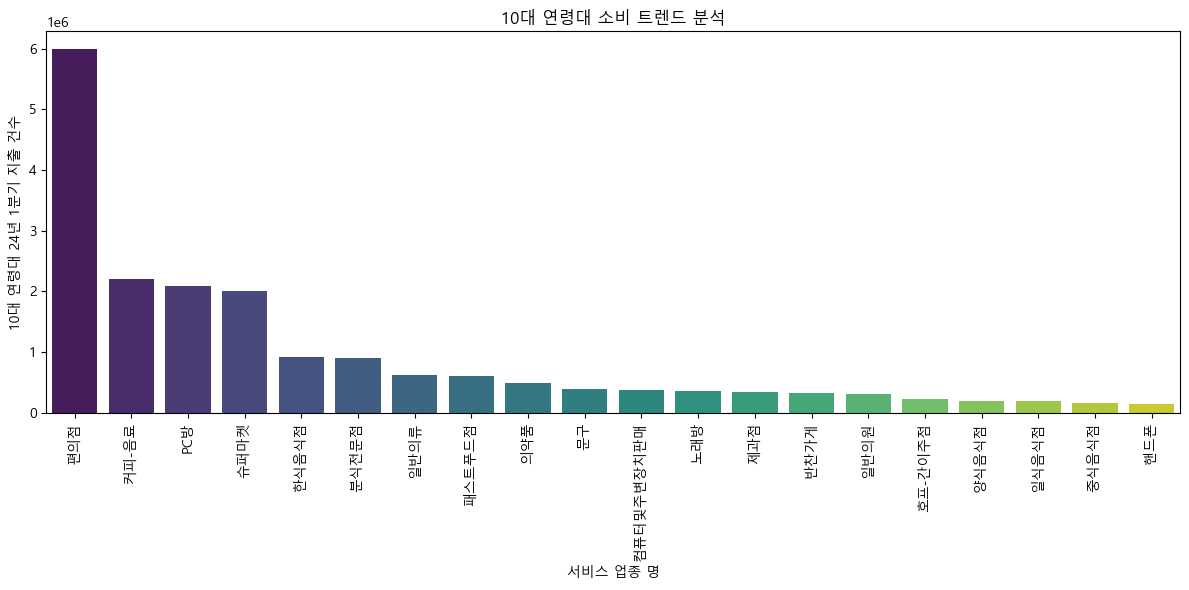

In [46]:
# X: '서비스_업종_코드', Y: '연령대_10_매출_건수' 시각화

df_MZ_comsumer_trend_sorted = df_combined.sort_values(by='연령대_10_매출_건수', ascending=False)
df_MZ_comsumer_trend_sorted_top20 = df_MZ_comsumer_trend_sorted.head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_MZ_comsumer_trend_sorted_top20, x='서비스_업종_코드_명', y='연령대_10_매출_건수', ci=None, palette='viridis')
plt.xticks(rotation=90)
plt.title('10대 연령대 소비 트렌드 분석')
plt.xlabel('서비스 업종 명')
plt.ylabel('10대 연령대 24년 1분기 지출 건수')
plt.tight_layout()
plt.show()

10대 인구 분포 상위 6개 지역에서 청소년들이 가장 많이 지출한 서비스 업종은 편의점, 한식음식점, 일반의류, 커피-음료, 분식전문점이 주를 이루었다.  

비교집단으로 10대를 제외한 다른 연령대로 선정해 소비 지출 패턴을 비교 분석해보기로 했다.

C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_27408\2180496557.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_30_comsumer_trend_sorted_top20, x='서비스_업종_코드_명', y='연령대_30_매출_건수', ci=None, palette='viridis')
C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_27408\2180496557.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_30_comsumer_trend_sorted_top20, x='서비스_업종_코드_명', y='연령대_30_매출_건수', ci=None, palette='viridis')


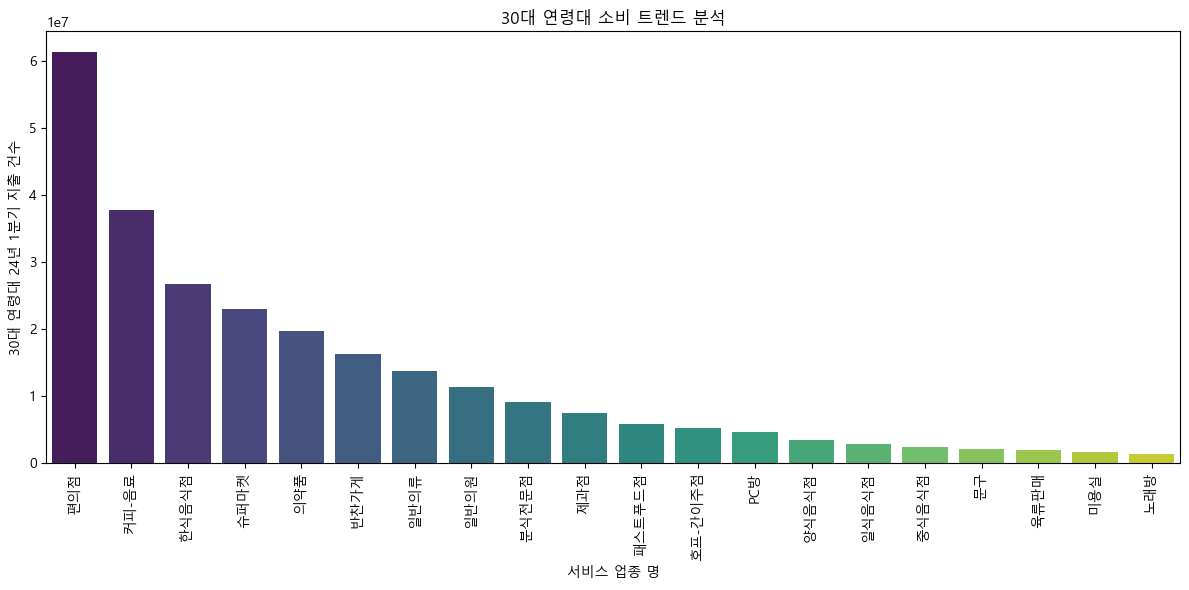

In [47]:
# X: '서비스_업종_코드', Y: '연령대_30_매출_금액' 시각화

df_30_comsumer_trend_sorted = df_combined.sort_values(by='연령대_30_매출_건수', ascending=False)
df_30_comsumer_trend_sorted_top20 = df_30_comsumer_trend_sorted.head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_30_comsumer_trend_sorted_top20, x='서비스_업종_코드_명', y='연령대_30_매출_건수', ci=None, palette='viridis')
plt.xticks(rotation=90)
plt.title('30대 연령대 소비 트렌드 분석')
plt.xlabel('서비스 업종 명')
plt.ylabel('30대 연령대 24년 1분기 지출 건수')
plt.tight_layout()
plt.show()

C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_27408\368658494.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_40_comsumer_trend_sorted_top20, x='서비스_업종_코드_명', y='연령대_40_매출_금액', ci=None, palette='viridis')
C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_27408\368658494.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_40_comsumer_trend_sorted_top20, x='서비스_업종_코드_명', y='연령대_40_매출_금액', ci=None, palette='viridis')


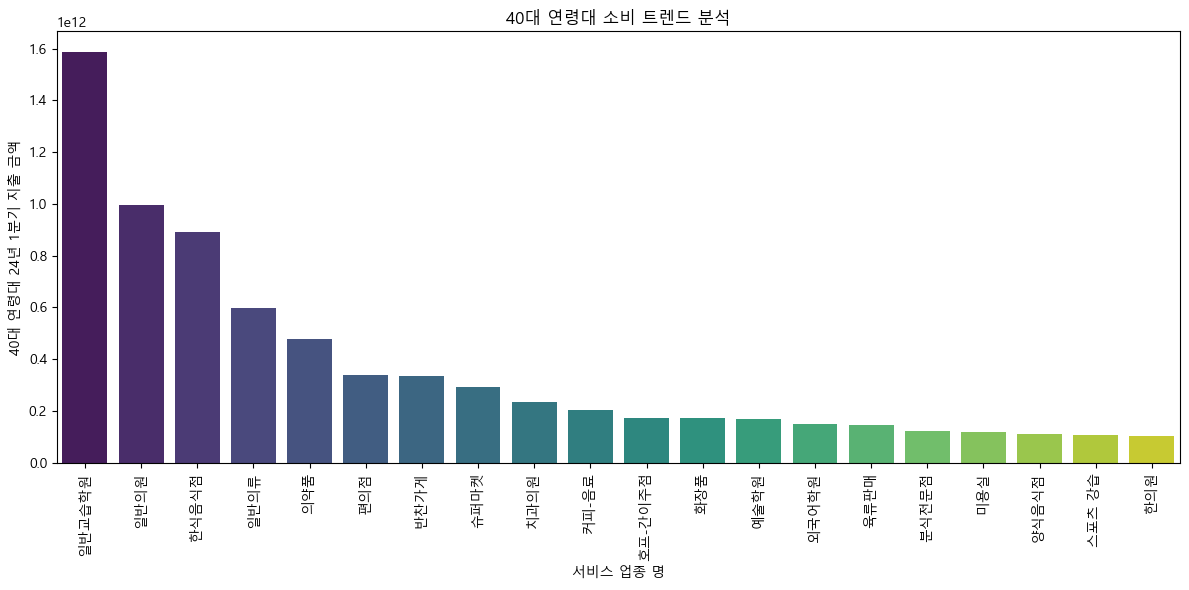

In [ ]:
# X: '서비스_업종_코드', Y: '연령대_40_매출_금액' 시각화

df_40_comsumer_trend_sorted = df_combined.sort_values(by='연령대_40_매출_지수', ascending=False)
df_40_comsumer_trend_sorted_top20 = df_40_comsumer_trend_sorted.head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_40_comsumer_trend_sorted_top20, x='서비스_업종_코드_명', y='연령대_40_매출_지수', ci=None, palette='viridis')
plt.xticks(rotation=90)
plt.title('40대 연령대 소비 트렌드 분석')
plt.xlabel('서비스 업종 명')
plt.ylabel('40대 연령대 24년 1분기 지출 금액')
plt.tight_layout()
plt.show()

연령별 30,40대와 비교했을 때 10대에서 눈에 띄는 서비스 업종은 PC방, 서점, 노래방, 문구, 패스트푸드 였다.    
이러한 매출 인사이트를 활용해볼 수 있다면 

### 강동구 MZ 세대 월별 서비스 업종 매출 비교 분석

'기준_년분기_코드', '행정동_코드', '행정동_코드_명', '서비스_업종_코드', '서비스_업종_코드_명' 컬럼을 기준으로 group by

In [6]:
# '기준_년분기_코드', '행정동_코드', '행정동_코드_명', '서비스_업종_코드', '서비스_업종_코드_명' 컬럼을 기준으로 group by 후 다 더한다. 

df_grouped = df.groupby(['기준_년분기_코드', '행정동_코드', '행정동_코드_명', '서비스_업종_코드', '서비스_업종_코드_명']).sum().reset_index()
df_grouped.head(5)

,기준_년분기_코드,행정동_코드,행정동_코드_명,서비스_업종_코드,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,월요일_매출_금액,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수
0,20241,11110515,청운효자동,CS100001,한식음식점,3282036149,102492,2359720647,922315502,381912382,...,25725,1622,49367,41053,470,12429,22034,18544,19637,17313
1,20241,11110515,청운효자동,CS100003,일식음식점,315907116,11835,225051104,90856012,26359701,...,2683,161,4925,6023,204,3395,2772,1733,1966,879
2,20241,11110515,청운효자동,CS100004,양식음식점,2582745698,49217,1540711320,1042034378,148589304,...,16503,2787,14393,32370,233,13771,14934,7816,6618,3394
3,20241,11110515,청운효자동,CS100005,제과점,548138245,41460,335822266,212315979,48215205,...,11458,351,13280,26768,216,8425,10838,7637,7641,5291
4,20241,11110515,청운효자동,CS100007,치킨전문점,78178614,2965,48075887,30102727,6755318,...,1889,496,1467,1406,24,303,667,593,747,537


In [7]:
# '행정동_코드'에서 11740으로 시작하는 행만 추출
df_gangdong = df_grouped[df_grouped['행정동_코드'].astype(str).str.startswith('11740')]

df_gangdong.head()

,기준_년분기_코드,행정동_코드,행정동_코드_명,서비스_업종_코드,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,월요일_매출_금액,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수
16304,20241,11740515,강일동,CS100001,한식음식점,2276964954,55710,1478726178,798238776,261235079,...,20450,2268,32327,18336,135,2859,9589,13343,13905,10832
16305,20241,11740515,강일동,CS100002,중식음식점,83459452,3167,71519777,11939675,10179596,...,755,0,2238,626,8,280,1003,691,569,312
16306,20241,11740515,강일동,CS100005,제과점,616842171,58704,531069679,85772492,87091055,...,13121,2189,27600,29057,159,5014,14138,17105,10886,9356
16307,20241,11740515,강일동,CS100006,패스트푸드점,554682618,57000,364688813,189993805,74509759,...,16752,1668,34898,21802,640,7690,18053,17254,8198,4865
16308,20241,11740515,강일동,CS100007,치킨전문점,171370362,5991,113519058,57851304,17054081,...,2891,2134,3797,2041,42,624,1150,1439,1690,894


In [8]:
df_gangdong.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2935 entries, 16304 to 67899
Data columns (total 53 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   기준_년분기_코드        2935 non-null   int64 
 1   행정동_코드           2935 non-null   int64 
 2   행정동_코드_명         2935 non-null   object
 3   서비스_업종_코드        2935 non-null   object
 4   서비스_업종_코드_명      2935 non-null   object
 5   당월_매출_금액         2935 non-null   int64 
 6   당월_매출_건수         2935 non-null   int64 
 7   주중_매출_금액         2935 non-null   int64 
 8   주말_매출_금액         2935 non-null   int64 
 9   월요일_매출_금액        2935 non-null   int64 
 10  화요일_매출_금액        2935 non-null   int64 
 11  수요일_매출_금액        2935 non-null   int64 
 12  목요일_매출_금액        2935 non-null   int64 
 13  금요일_매출_금액        2935 non-null   int64 
 14  토요일_매출_금액        2935 non-null   int64 
 15  일요일_매출_금액        2935 non-null   int64 
 16  시간대_00~06_매출_금액  2935 non-null   int64 
 17  시간대_06~11_매출_금액  2935 non-null   

In [9]:
# '기준_년분기_코드', '행정동_코드', '행정동_코드_명', '서비스_업종_코드', '서비스_업종_코드_명', '연령대_10_매출_금액', '연령대_20_매출_금액', '연령대_10_매출_건수', '연령대_20_매출_건수'
# '당월_매출_금액',	'당월_매출_건수' 컬럼 선택

df_gangdong = df_gangdong[['기준_년분기_코드', '행정동_코드', '행정동_코드_명', '서비스_업종_코드', '서비스_업종_코드_명',
                           '당월_매출_금액', '당월_매출_건수',
                           '연령대_10_매출_금액', '연령대_20_매출_금액', '연령대_10_매출_건수', '연령대_20_매출_건수',
                           ]]

df_gangdong.head(5)

,기준_년분기_코드,행정동_코드,행정동_코드_명,서비스_업종_코드,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,연령대_10_매출_금액,연령대_20_매출_금액,연령대_10_매출_건수,연령대_20_매출_건수
16304,20241,11740515,강일동,CS100001,한식음식점,2276964954,55710,1541544,86446008,135,2859
16305,20241,11740515,강일동,CS100002,중식음식점,83459452,3167,72167,7337007,8,280
16306,20241,11740515,강일동,CS100005,제과점,616842171,58704,708206,35316813,159,5014
16307,20241,11740515,강일동,CS100006,패스트푸드점,554682618,57000,5139545,64937366,640,7690
16308,20241,11740515,강일동,CS100007,치킨전문점,171370362,5991,906229,16092292,42,624


In [10]:
df_gangdong['서비스_업종_코드_명'].unique()

array(['한식음식점', '중식음식점', '제과점', '패스트푸드점', '치킨전문점', '분식전문점', '커피-음료',
       '일반교습학원', '외국어학원', '예술학원', '스포츠 강습', '일반의원', '치과의원', '한의원', '당구장',
       '스포츠클럽', '자동차수리', '미용실', '세탁소', '슈퍼마켓', '편의점', '육류판매', '수산물판매',
       '청과상', '반찬가게', '일반의류', '안경', '의약품', '서적', '문구', '화초', '일식음식점',
       '양식음식점', '호프-간이주점', '골프연습장', 'PC방', '네일숍', '피부관리실', '노래방', '철물점',
       '인테리어', '부동산중개업', '여관', '핸드폰', '신발', '가방', '시계및귀금속', '의료기기', '화장품',
       '자전거 및 기타운송장비', '섬유제품', '애완동물', '전자상거래업', '미곡판매', '가전제품수리',
       '컴퓨터및주변장치판매', '자동차미용', '운동/경기용품', '가전제품', '조명용품', '가구', '완구'],
      dtype=object)

강동구에서 MZ세대는 어떤 서비스업종에 가장 많이 소비를 할까?

In [11]:
# 24년 1분기 강동구 MZ 소비 트렌드 분석
df_gangdong_MZ_comsumer_trend = df_gangdong.groupby(['서비스_업종_코드', '서비스_업종_코드_명']).sum().reset_index()

df_gangdong_MZ_comsumer_trend.head(5)

,서비스_업종_코드,서비스_업종_코드_명,기준_년분기_코드,행정동_코드,행정동_코드_명,당월_매출_금액,당월_매출_건수,연령대_10_매출_금액,연령대_20_매출_금액,연령대_10_매출_건수,연령대_20_매출_건수
0,CS100001,한식음식점,1376490,798360480,강일동상일동명일1동명일2동고덕1동고덕2동암사1동암사2동암사3동천호1동천호2동천호3동...,514019255105,14669529,1458490770,39819844115,71130,1194898
1,CS100002,중식음식점,1234791,716176575,강일동상일동명일1동명일2동고덕1동고덕2동암사1동암사2동천호1동천호2동천호3동성내1동...,20434025087,827334,111164160,2494614026,7975,90854
2,CS100003,일식음식점,1032369,598770365,상일동명일1동명일2동암사1동암사2동천호1동천호2동천호3동성내1동성내2동성내3동길동강...,26171145382,655616,314218002,3871914524,21942,105178
3,CS100004,양식음식점,890670,516586980,상일동명일1동명일2동암사3동천호2동천호3동성내1동성내2동성내3동길동둔촌2동상일동명일...,22674902285,600590,236589772,3789258325,11636,110391
4,CS100005,제과점,1295520,751398280,강일동상일동명일1동명일2동고덕2동암사1동암사2동암사3동천호1동천호2동천호3동성내1동...,48617618175,4812028,282472914,3805129855,48622,476072


24년 1분기 강동구 10대 청소년 지출 결과 시각화

C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_27408\4262710651.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_gangdong_MZ_comsumer_trend_sorted_top20, x='서비스_업종_코드_명', y='연령대_10_매출_금액', ci=None, palette='viridis')
C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_27408\4262710651.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_gangdong_MZ_comsumer_trend_sorted_top20, x='서비스_업종_코드_명', y='연령대_10_매출_금액', ci=None, palette='viridis')


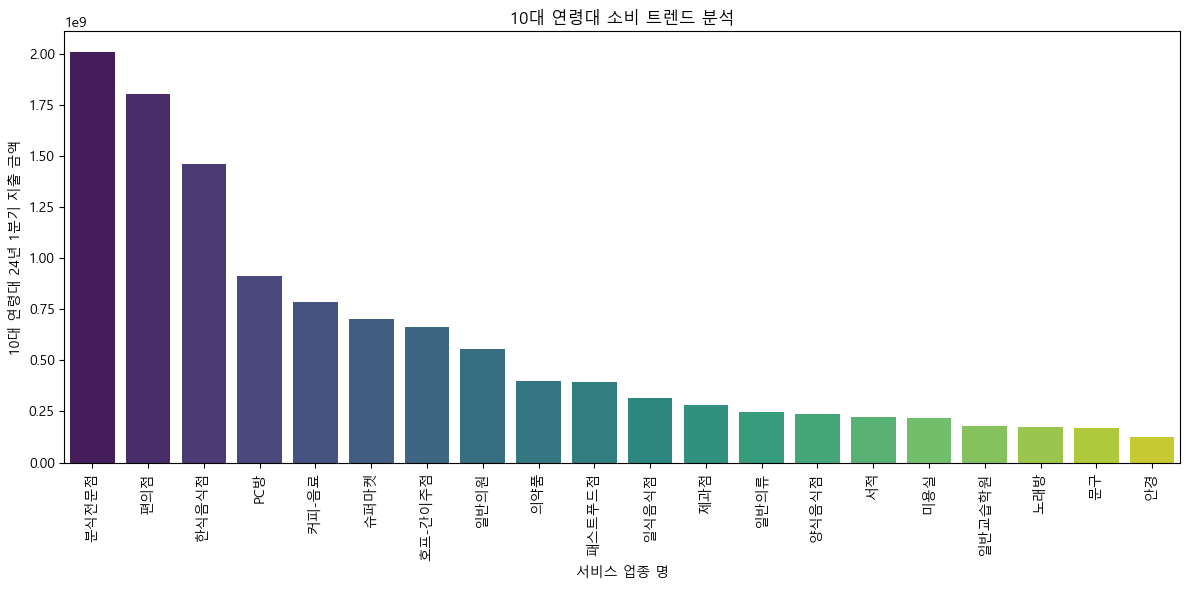

In [ ]:
# X: '서비스_업종_코드', Y: '연령대_10_매출_금액' 시각화

df_gangdong_MZ_comsumer_trend_sorted = df_gangdong_MZ_comsumer_trend.sort_values(by='연령대_10_매출_금액', ascending=False)
df_gangdong_MZ_comsumer_trend_sorted_top20 = df_gangdong_MZ_comsumer_trend_sorted.head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_gangdong_MZ_comsumer_trend_sorted_top20, x='서비스_업종_코드_명', y='연령대_10_매출_금액', ci=None, palette='viridis')
plt.xticks(rotation=90)
plt.title('10대 연령대 소비 트렌드 분석')
plt.xlabel('서비스 업종 명')
plt.ylabel('10대 연령대 24년 1분기 지출 금액')
plt.tight_layout()
plt.show()

C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_27408\2119685314.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_gangdong_20_comsumer_trend_sorted_top20, x='서비스_업종_코드_명', y='연령대_20_매출_금액', ci=None, palette='viridis')
C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_27408\2119685314.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_gangdong_20_comsumer_trend_sorted_top20, x='서비스_업종_코드_명', y='연령대_20_매출_금액', ci=None, palette='viridis')


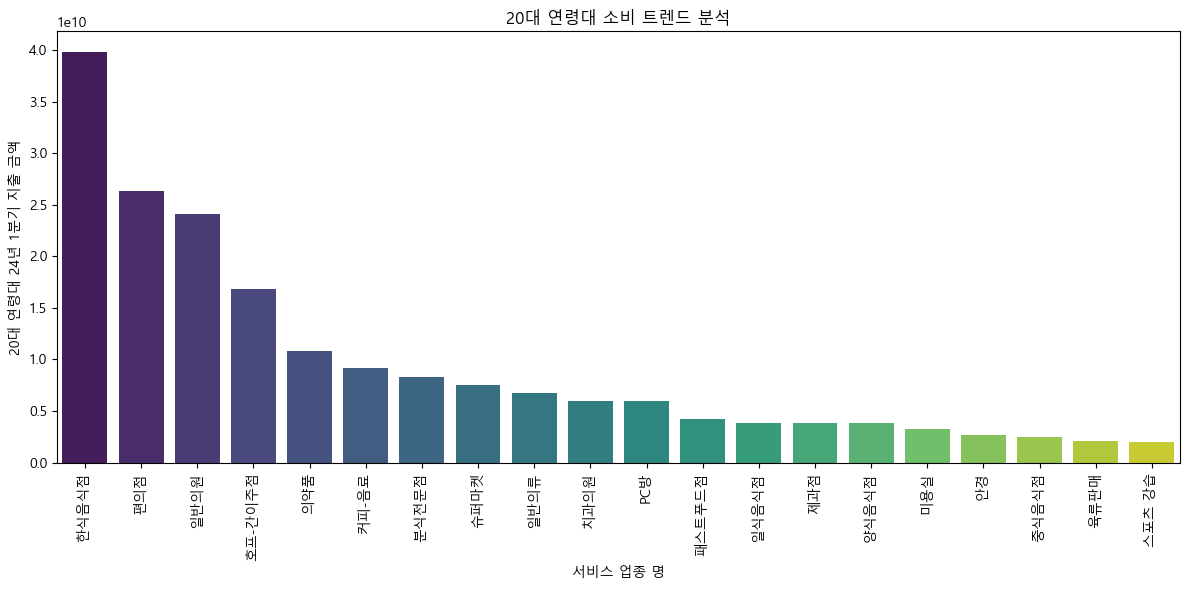

In [18]:
# 24년 1분기 강동구 MZ 소비 트렌드 분석 - 20대
df_gangdong_20_comsumer_trend = df_gangdong.groupby(['서비스_업종_코드', '서비스_업종_코드_명']).sum().reset_index()

df_gangdong_20_comsumer_trend.head(5)

# X: '서비스_업종_코드', Y: '연령대_10_매출_금액' 시각화

df_gangdong_20_comsumer_trend_sorted = df_gangdong_20_comsumer_trend.sort_values(by='연령대_20_매출_금액', ascending=False)
df_gangdong_20_comsumer_trend_sorted_top20 = df_gangdong_20_comsumer_trend_sorted.head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_gangdong_20_comsumer_trend_sorted_top20, x='서비스_업종_코드_명', y='연령대_20_매출_금액', ci=None, palette='viridis')
plt.xticks(rotation=90)
plt.title('20대 연령대 소비 트렌드 분석')
plt.xlabel('서비스 업종 명')
plt.ylabel('20대 연령대 24년 1분기 지출 금액')
plt.tight_layout()
plt.show()

### 강남구 MZ 세대 24년 1분기 서비스 업종 매출 비교 분석

In [21]:
# 24년 1분기 강남구 MZ 소비 트렌드 분석

# '행정동_코드'에서 11680으로 시작하는 행만 추출
df_gangnam = df_grouped[df_grouped['행정동_코드'].astype(str).str.startswith('11680')]

df_gangnam.head()

df_gangnam_MZ_comsumer_trend = df_gangnam.groupby(['서비스_업종_코드', '서비스_업종_코드_명']).sum().reset_index()

df_gangnam_MZ_comsumer_trend.head(5)

,서비스_업종_코드,서비스_업종_코드_명,기준_년분기_코드,행정동_코드,행정동_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,월요일_매출_금액,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수
0,CS100001,한식음식점,1781340,1027895772,신사동논현1동논현2동압구정동청담동삼성1동삼성2동대치1동대치2동대치4동역삼1동역삼2동...,1959963350772,45189180,1573434048325,386529302447,285050547734,...,11697058,3614667,21784229,14811825,332663,5702912,10560891,8296457,6829041,4873877
1,CS100002,중식음식점,1619400,934450252,신사동논현1동논현2동압구정동청담동삼성1동삼성2동대치1동대치2동대치4동역삼1동역삼2동...,208314031364,4921323,159140424951,49173606413,28104404008,...,1435286,215036,2281143,1790601,74224,771366,1164084,948162,714151,399743
2,CS100003,일식음식점,1619400,934450252,신사동논현1동논현2동압구정동청담동삼성1동삼성2동대치1동대치2동대치4동역삼1동역삼2동...,272012267021,5699328,217199580707,54812686314,37658815305,...,1608764,541386,2458419,2285508,90565,1112745,1588777,943987,679738,328146
3,CS100004,양식음식점,1538430,887727292,신사동논현1동논현2동압구정동청담동삼성1동삼성2동대치1동대치2동대치4동역삼1동역삼2동...,363418564430,6082706,262855506753,100563057677,40301280119,...,1791155,549651,2383542,2800955,97586,1233250,1764239,1056645,728895,303917
4,CS100005,제과점,1538430,887727292,신사동논현1동논현2동압구정동청담동삼성1동삼성2동대치1동대치2동대치4동역삼1동역삼2동...,107355635384,9389698,83167782430,24187852954,15313358753,...,2128002,321208,3333768,5226627,86484,1302766,2233112,2172585,1580452,1184924


C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_27408\4064700613.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_gangnam_MZ_comsumer_trend_sorted_top20, x='서비스_업종_코드_명', y='연령대_10_매출_금액', ci=None, palette='viridis')
C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_27408\4064700613.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_gangnam_MZ_comsumer_trend_sorted_top20, x='서비스_업종_코드_명', y='연령대_10_매출_금액', ci=None, palette='viridis')


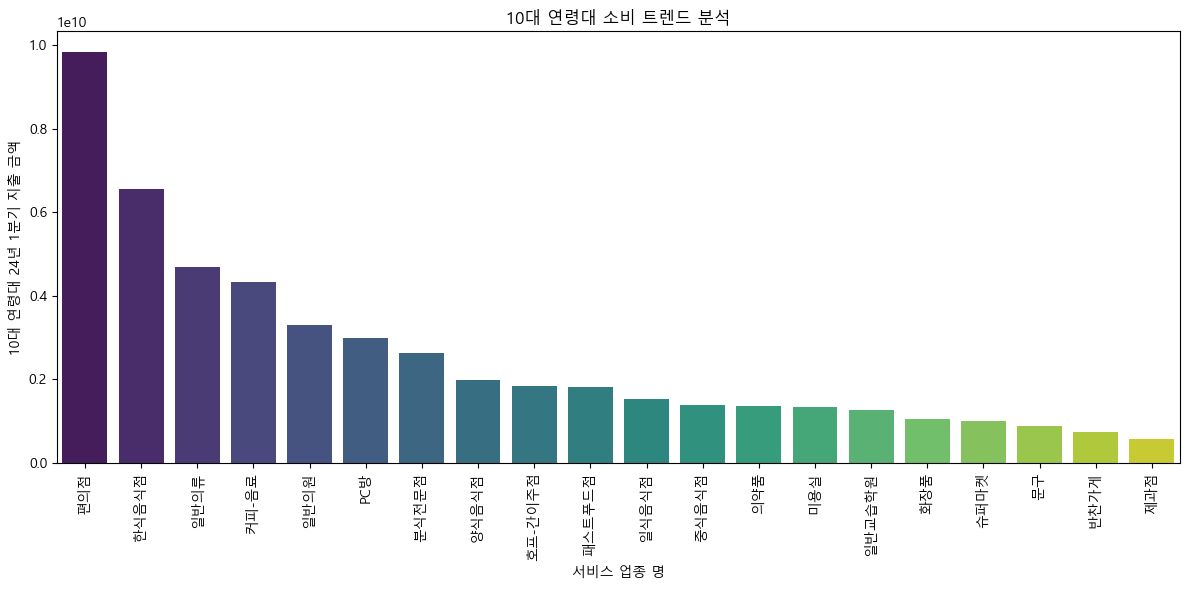

In [22]:
# X: '서비스_업종_코드', Y: '연령대_10_매출_금액' 시각화

df_gangnam_MZ_comsumer_trend_sorted = df_gangnam_MZ_comsumer_trend.sort_values(by='연령대_10_매출_금액', ascending=False)
df_gangnam_MZ_comsumer_trend_sorted_top20 = df_gangnam_MZ_comsumer_trend_sorted.head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_gangnam_MZ_comsumer_trend_sorted_top20, x='서비스_업종_코드_명', y='연령대_10_매출_금액', ci=None, palette='viridis')
plt.xticks(rotation=90)
plt.title('10대 연령대 소비 트렌드 분석')
plt.xlabel('서비스 업종 명')
plt.ylabel('10대 연령대 24년 1분기 지출 금액')
plt.tight_layout()
plt.show()